# Import Libraries

In [1]:
import torch
from torch import nn
from torch import optim
try:
    import torch_directml # for non-CUDA GPU acceleration
except:
    print('Could not import directml')
print(torch.__version__)

2.4.1+cpu


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.cluster import KMeans
import hdbscan
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from transformers import BlipProcessor, BlipForConditionalGeneration
import re
import spacy

c:\Users\Matthew\miniconda3\envs\pytdml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define Functions

In [3]:
# Function to load images from subfolders and preprocess them
def load_images_from_folder(root_folder, image_size=(500 , 375)):
    """
    Loads images from subfolders, converts them to grayscale, resizes them,
    and flattens them into feature vectors.

    Parameters:
        root_folder (str): The path to the main folder containing subfolders of images.
        image_size (tuple): The fixed size to which images are resized.

    Returns:
        np.array: Image feature vectors.
        np.array: Corresponding labels.
        list: Names of subfolders (classes).
    """
    image_data = []  # Stores flattened pixel values of images
    labels = []  # Stores the numeric labels for each image
    label_names = []  # Stores the actual subfolder (category) names

    # Loop through subfolders (each representing a different category)
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)  # Store subfolder name as a label
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    # Open image
                    with Image.open(file_path) as img:
                        # img = img.convert("L")  # Convert to grayscale for consistency
                        img = img.resize(image_size)  # Resize to a fixed size
                        image_data.append(np.array(img))  # store image
                        labels.append(label)  # Assign a numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names

In [4]:
# Function to load images from subfolders and extract BLIP image embeddings
# Uses GPU acceleration if available
def get_blip_image_embedding_acc(images, model, processor, device, batch_size=8):
    image_embeds_list = []

    model.to(device)

    # Process images in mini-batches
    for i in range(0, images.shape[0], batch_size):
        mini_batch = images[i:i + batch_size]
        inputs = processor(images=mini_batch, return_tensors="pt")
        pixel_values=inputs["pixel_values"].to(device)

        with torch.no_grad():
            vision_outputs = model.vision_model(pixel_values=pixel_values)
            mini_batch_embeds = vision_outputs.last_hidden_state[:, 0, :]  # Extract [CLS] token embeddings
            image_embeds_list.append(mini_batch_embeds.cpu())

    # Concatenate all mini-batch embeddings
    image_embeds = torch.cat(image_embeds_list, dim=0).numpy()

    model.cpu()

    return image_embeds

In [5]:
# Function to load images from subfolders and extract BLIP image embeddings
def get_blip_image_embedding(images, model, processor):
    image_data = []  # Stores image feature vectors
    
    for i in range(images.shape[0]):
        img = images[i]
        
        # Get BLIP image embedding
        inputs = processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"]
        with torch.no_grad():  
            vision_outputs = model.vision_model(pixel_values=pixel_values)
        image_embeds = vision_outputs.last_hidden_state[:, 0, :]

        image_data.append(image_embeds.flatten().numpy())

    return np.array(image_data)

In [6]:
# Function to plot the distribution of classes in a cluster
def plot_cluster_distribution(y_true, y_pred, label_names):
    # get clusters
    cluster_count = 0

    clusters = np.unique(y_pred)

    matrix = np.zeros((clusters.shape[0], len(label_names)))

    for cluster in clusters:
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
        true_labels_in_cluster = y_true[cluster_indices]  # Get true labels

        counter = Counter(true_labels_in_cluster)

        for item in counter.items():
            matrix[cluster_count][int(item[0])] = item[1]

        cluster_count += 1


    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues", xticklabels=label_names, yticklabels=clusters)
    plt.xlabel("Labels")
    plt.ylabel("Cluster")
    plt.title("Clustering Label Distribution")
    plt.show()

        

In [7]:
# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    # print(label_names)
    sliced_list = [label_names[int(i)] for i in np.unique(y_true)]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sliced_list, yticklabels=sliced_list)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of Clustering")
    plt.show()

In [8]:
# Function to generate captions for images
def generate_caption(images, model, processor, device, batch_size=8):
    """Generates a caption describing the type of event in the image."""

    # print("Generating Captions...")

    caption_list = []
    clean_caption = []

    text_prompt = "this event is called a"

    model.to(device)

    # Process images in mini-batches
    for i in range(0, images.shape[0], batch_size):
        mini_batch = images[i:i + batch_size]
        inputs = processor(images=mini_batch, text=text_prompt, return_tensors="pt")
        pixel_values=inputs["pixel_values"].to(device)

        with torch.no_grad():
            with torch.no_grad():
                generated_ids = model.generate(pixel_values, max_length=50)
            captions = processor.batch_decode(generated_ids, skip_special_tokens=True)
            caption_list = caption_list + captions

    model.cpu()

    # Remove the prompt from the output if it appears
    for caption in caption_list:
        clean_caption.append(caption.replace(text_prompt, "").strip())

    return clean_caption

In [9]:
def extract_key_phrases(captions, nlp):
    """Extracts the most common meaningful phrases from a list of captions."""
    # print("Naming Albums...")

    processed_text = " ".join(captions)
    doc = nlp(processed_text)
    
    # Extract meaningful nouns and proper nouns
    keywords = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"] and not token.is_stop]
    
    # Get most common phrases
    common_phrases = Counter(keywords).most_common(3)
    return " ".join([word for word, _ in common_phrases])

In [10]:
def get_cluster_name(images, model, processor, nlp, device, batch_size=8):
    """Determines a cluster name based on captions extracted from images."""
    captions = generate_caption(images, model, processor, device, batch_size)
    return extract_key_phrases(captions, nlp)

In [11]:
# function to perform clustering
def cluster_images(clusterer, data):
    y_pred = clusterer.fit_predict(data)

    return clusterer, y_pred

In [12]:
# Function to clustering accuracy evaluate accuracy
def evaluate_clustering(y_pred, y_true, label_names=None, output_text=False):
    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}

    accuracy = 0
    overall = 0

    # get indices of the clustered images
    indices = y_pred >= 0

    # get clusters
    clusters = np.unique(y_pred)

    # eliminated unclustered cluster
    if clusters[0] == -1:
        clusters = clusters[1:]

    # report on ungrouped images
    total = y_pred.shape[0]
    ungroupped = total - indices.sum()

    if output_text:
        print(f"Number of unassigned images: {ungroupped} ({ungroupped/total:.2%})%")

    if ungroupped < total:
        # use only vlaues that have been clustered
        y_pred = y_pred[indices]
        y_true = y_true[indices]
        
        for cluster in clusters:
            cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
            true_labels_in_cluster = y_true[cluster_indices]  # Get true labels
            
            if len(true_labels_in_cluster) > 0:
                most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
                cluster_to_label[cluster] = int(most_common_label)

        # Convert predicted clusters into corresponding labels
        y_pred_mapped = np.array([cluster_to_label[c] for c in y_pred])

        if label_names != None and output_text:
            # show cluster proposed album
            for cluster in clusters:
                print(f"Cluster {cluster}: True Label = '{label_names[cluster_to_label[cluster]]}'")

        # Calculate clustering accuracy
        accuracy = accuracy_score(y_true, y_pred_mapped)
        overall = accuracy * indices.sum() / total

        if label_names != None:
            # Show confusion matrix
            plot_confusion_matrix(y_true, y_pred_mapped, label_names)

    if output_text:
            print(f"Clustering accuracy: {accuracy:.2%} (Overall: {overall:.2%})")
    
    return accuracy, overall, ungroupped

In [13]:
def name_clusters(model, processor, y_pred, images, nlp, device, batch_size=8, sample_size=5):
    cluster_proposed_names = {}

    # get clusters
    clusters = np.unique(y_pred)

    # eliminated unclustered cluster
    if clusters[0] == -1:
        clusters = clusters[1:]

    for cluster in clusters:
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster

        # Select a subset of images to caption for cluster naming
        if sample_size > 0:
            sample_indices = np.random.choice(cluster_indices, min(sample_size, len(cluster_indices)), replace=False)
            sample_images = images[sample_indices]
        else:
            sample_images = images[cluster_indices]


        cluster_proposed_names[cluster] = get_cluster_name(sample_images, model=model, processor=processor, nlp=nlp, device=device, batch_size=batch_size)

    # Display proposed names for each cluster
    print("\nProposed Cluster Names:")
    for cluster, name in cluster_proposed_names.items():
        print(f"Cluster {cluster}: Proposed Name = '{name}'")

In [14]:
def calculate_gini_loss_from_numpy(loss, y_pred, y_true):
    if isinstance(y_pred, np.ndarray):
        y_pred = torch.Tensor(y_pred)

    if isinstance(y_true, np.ndarray):
        y_true = torch.Tensor(y_true)

    loss_val = loss(y_pred, y_true)

    print(f"Clustered Gini Loss is: {loss_val}")

    return loss_val

In [15]:
def shannon_entropy(probabilities):
    # probabilities = np.array(probabilities)
    return -np.sum(probabilities * np.log2(probabilities, where=(probabilities > 0)))

In [16]:
def calculate_average_entropy(y_pred, y_true):
    # initialize entropy list
    avg_entropy = 0.0
    entropies = []

    # get clusters
    clusters, cluster_counts = np.unique(y_pred, return_counts=True)
    
    # get class labels
    labels, label_counts = np.unique(y_true, return_counts=True)

    # eliminated unclustered cluster
    if clusters[0] == -1:

        if clusters.shape[0] <= 1:
            return -1, []

        # eliminated unclustered points
        clusters = clusters[1:]
        cluster_counts = cluster_counts[1:]

    prob_mat = np.zeros((clusters.shape[0], labels.shape[0]))

    for cluster in clusters:
        indices = y_pred == cluster # get cluster indices
        total = indices.sum()
        truth = y_true[indices]

        idx, counts = np.unique(truth, return_counts=True)

        for i in range(idx.shape[0]):
            prob_mat[int(cluster)][int(idx[i])] = counts[i]

        prob_mat[int(cluster)] /= total

    for row in range(prob_mat.shape[0]):
        entropy = shannon_entropy(prob_mat[row])
        avg_entropy += cluster_counts[row] * entropy
        entropies.append(entropy)

    avg_entropy /= cluster_counts.sum() #clusters.shape[0]

    return avg_entropy, entropies

# Define Loss Function

In [17]:
### DOESN'T WORKS SINCE DETACHES TENSORS FROM COMPUTATION GRAPH
class ClusteredGiniLoss(nn.Module):
    """
    Computes Gini Loss for Clusters

    Args:
        alpha - punishes model for unclustered datapoints
    """
    def __init__(self, alpha=0.5):
        super(ClusteredGiniLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):

        # initialize loss
        loss_value = 0.0

        # get clusters
        clusters, cluster_counts = y_pred.unique(return_counts=True)
        
        # get class labels
        labels, label_counts = y_true.unique(return_counts=True)

        # eliminated unclustered cluster
        if clusters[0] == -1:
            # pushish unclustered datapoints
            loss_value += self.alpha * cluster_counts[0]

            # eliminated unclustered points
            clusters = clusters[1:]
            cluster_counts = cluster_counts[1:]

        # setup probablility matrix
        prob_mat = torch.zeros((clusters.shape[0], labels.shape[0]))

        # calculate probabilities of each class for every cluster
        for cluster in clusters:
            indices = y_pred == cluster # get cluster indices
            total = indices.sum()
            truth = y_true[indices]

            idx, counts = truth.unique(return_counts=True)

            for i in range(idx.shape[0]):
                prob_mat[int(cluster)][int(idx[i])] = counts[i]

            prob_mat[int(cluster)] /= total

        # Ensure y_pred is a probability distribution (softmax output)
        prob_mat = torch.softmax(prob_mat, dim=1)

        # Compute Gini impurity for each sample in the batch
        gini = 1 - torch.sum(prob_mat ** 2, dim=1)  # Gini = 1 - sum(p_i^2)

        loss_value += torch.sum(gini)

        # Average Gini impurity over the batch
        return loss_value
    
"""
FOOD FOR THOUGHT
- what is a good alpha value that penalizes the non-clustered photos?
- how can we account for more clusters to not be punished so heavily
- should the cluster loss be averaged (lowers punishment for clusters, but also punishes poor clusters less)
- note GINI LOSS range is [0, 0.5]
"""

'\nFOOD FOR THOUGHT\n- what is a good alpha value that penalizes the non-clustered photos?\n- how can we account for more clusters to not be punished so heavily\n- should the cluster loss be averaged (lowers punishment for clusters, but also punishes poor clusters less)\n- note GINI LOSS range is [0, 0.5]\n'

In [18]:
class ModifiedTripletLoss(nn.Module):
    """
    Computes Triplet Loss for Clusters

    Args:
        alpha - punishes model for unclustered datapoints
    """
    def __init__(self, triplet_loss, clusterer):
        super(ModifiedTripletLoss, self).__init__()
        self.triplet_loss = triplet_loss
        self.clusterer = clusterer

    def forward(self, embeddings, y_true):

        # get clusters
        _, y_pred = cluster_images(self.clusterer, embeddings.cpu().detach().numpy())

        device = embeddings.device
        embeddings = embeddings.cpu()

        # y_pred = torch.Tensor(y_pred)#.to(device)

        # initialize loss
        loss_value = 0.0 #torch.nn.loss

        # get clusters
        clusters = np.unique(y_pred)#.cpu().unique(return_counts=True)

        y_true = y_true.squeeze().cpu().detach().numpy()
        
        # # get class labels
        # labels, label_counts = y_true.cpu().unique(return_counts=True)

        for cluster in clusters:
            # print(cluster)

            idx_mask = y_pred == cluster
            indices = np.where(y_pred == cluster)

            for idx in indices[0]:
                if cluster == -1:
                    pos_indices = np.where(y_true == y_true[idx])
                else:
                    pos_indices = np.where((y_true == y_true[idx]) & idx_mask)

                neg_indices = np.where((y_true != y_true[idx]) & idx_mask)

                for p_idx in pos_indices[0]:
                    if p_idx != idx:
                        print
                        if neg_indices[0].shape[0] > 0:
                            for n_idx in neg_indices[0]: 
                                loss_value += self.triplet_loss(embeddings[idx], embeddings[p_idx], embeddings[n_idx])
                        else:
                            loss_value += self.triplet_loss(embeddings[idx], embeddings[p_idx], torch.zeros(embeddings[0].shape))
                    else:
                        pass

        # return loss value
        return loss_value

In [19]:
class ModifiedBCE(nn.Module):
    """
    Computes Binary Cross Entropy Loss for Clusters

    Args:
        alpha - punishes model for unclustered datapoints
    """
    def __init__(self, bce_loss, clusterer):
        super(ModifiedBCE, self).__init__()
        self.bce_loss = bce_loss
        self.clusterer = clusterer

    def forward(self, embeddings, y_true):

        device = y_true.device

        # get clusters
        _, y_pred = cluster_images(self.clusterer, embeddings.cpu().detach().numpy())

        # get clusters
        clusters = np.unique(y_pred)

        y_labels = torch.zeros(y_pred.shape).to(device)

        for cluster in clusters:
            if cluster == -1:
                y_labels[y_pred == -1] == 0
            else:
                true_labels_in_cluster = y_true[y_pred == int(cluster)]
                most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
                
                y_labels[y_pred == int(cluster)] = most_common_label

                y_labels[y_pred == int(cluster)] = (y_labels[y_pred == int(cluster)] == y_true[y_pred == int(cluster)].squeeze()).to(torch.float32)

        y_labels[y_labels == 0] = 1e-9
        y_labels[y_labels == 1] = 1-1e-9

        print(y_labels.unique())

        loss_value = self.bce_loss(y_labels.unsqueeze(dim=-1), y_true)

        # return loss value
        return loss_value

# Generate Results

In [20]:
# Check if DirectML is available and print the device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if GPU is available
if torch_directml.is_available():
    device = torch_directml.device(0)  # Using the first available device
    print("Using DirectML with GPU.")
else:
    print(f"Using {device}.")

Using DirectML with GPU.


In [21]:
# set image folder
image_locations = "./Albums_Not_Grouped"

# Initialize BLIP processor and model for image captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Load spaCy English model for NLP processing
nlp = spacy.load("en_core_web_sm")

# Define loss
gini_loss = ClusteredGiniLoss(0.5)

In [22]:
# load data
images, y, labels = load_images_from_folder(root_folder=image_locations, image_size=(500,375))
X = get_blip_image_embedding_acc(model=model, processor=processor, images=images, device=device, batch_size=8)

## Results K-Means

In [23]:
kmeans = KMeans(n_clusters=len(labels), n_init=10)
kmeans_model, y_pred = cluster_images(clusterer=kmeans, data=X)

In [24]:
calculate_gini_loss_from_numpy(gini_loss, y_pred, y)

Clustered Gini Loss is: 6.85103702545166


tensor(6.8510)

Number of unassigned images: 0 (0.00%)%
Cluster 0: True Label = 'ThemePark'
Cluster 1: True Label = 'Graduation'
Cluster 2: True Label = 'ThemePark'
Cluster 3: True Label = 'Birthday2'
Cluster 4: True Label = 'Birthday'
Cluster 5: True Label = 'Personal_sports'
Cluster 6: True Label = 'Show'
Cluster 7: True Label = 'Graduation 2'


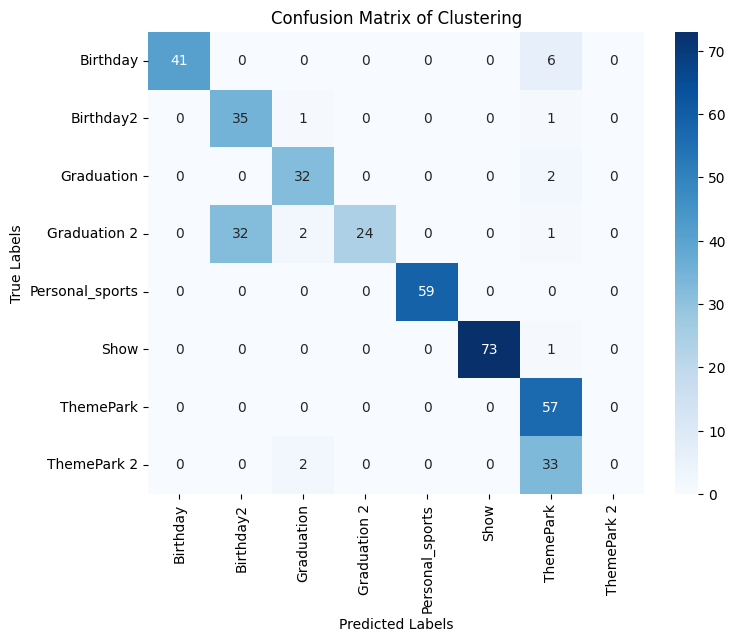

Clustering accuracy: 79.85% (Overall: 79.85%)


In [25]:
# evaluate model
indices = y_pred >= 0 # get only images that have a cluster assigned
acc = evaluate_clustering(y_pred=y_pred, label_names=labels, y_true=y, output_text=True)

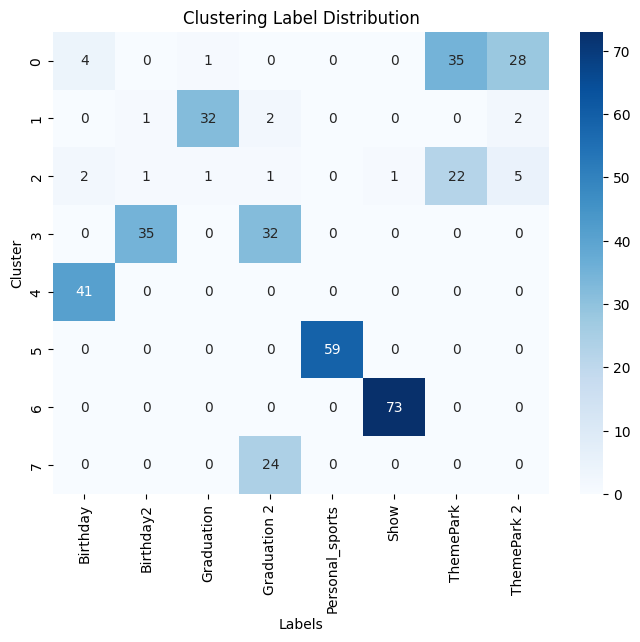

In [26]:
plot_cluster_distribution(y, y_pred, labels)

In [27]:
name_clusters(model, processor, y_pred, images, nlp, device)


Proposed Cluster Names:
Cluster 0: Proposed Name = 'goofy clock wall'
Cluster 1: Proposed Name = 'people crowd group'
Cluster 2: Proposed Name = 'people group fire'
Cluster 3: Proposed Name = 'man group people'
Cluster 4: Proposed Name = 'table man group'
Cluster 5: Proposed Name = 'skateboard boy man'
Cluster 6: Proposed Name = 'man stage outfit'
Cluster 7: Proposed Name = 'group girls jeep'


## Results HDBSCAN

In [28]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=X)

In [29]:
calculate_gini_loss_from_numpy(gini_loss, y_pred, y)

Clustered Gini Loss is: 61.89169692993164


tensor(61.8917)

Number of unassigned images: 100 (24.88%)%
Cluster 0: True Label = 'Birthday'
Cluster 1: True Label = 'ThemePark 2'
Cluster 2: True Label = 'ThemePark 2'
Cluster 3: True Label = 'Personal_sports'
Cluster 4: True Label = 'ThemePark'
Cluster 5: True Label = 'Birthday'
Cluster 6: True Label = 'Birthday'
Cluster 7: True Label = 'Show'
Cluster 8: True Label = 'Graduation 2'
Cluster 9: True Label = 'Graduation 2'
Cluster 10: True Label = 'Graduation 2'
Cluster 11: True Label = 'Birthday2'
Cluster 12: True Label = 'Graduation'
Cluster 13: True Label = 'Graduation'


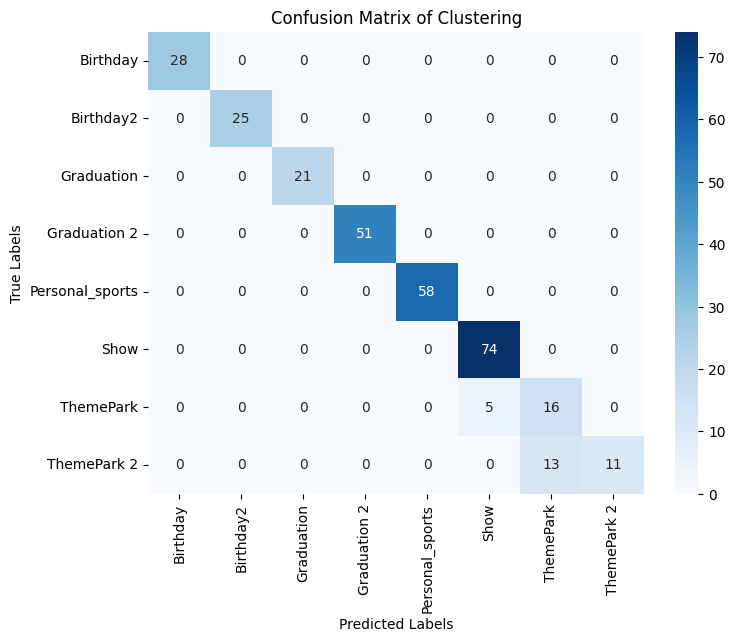

Clustering accuracy: 94.04% (Overall: 70.65%)


In [30]:
# evaluate model
indices = y_pred >= 0 # get only images that have a cluster assigned
acc = evaluate_clustering(y_pred=y_pred, label_names=labels, y_true=y, output_text=True)

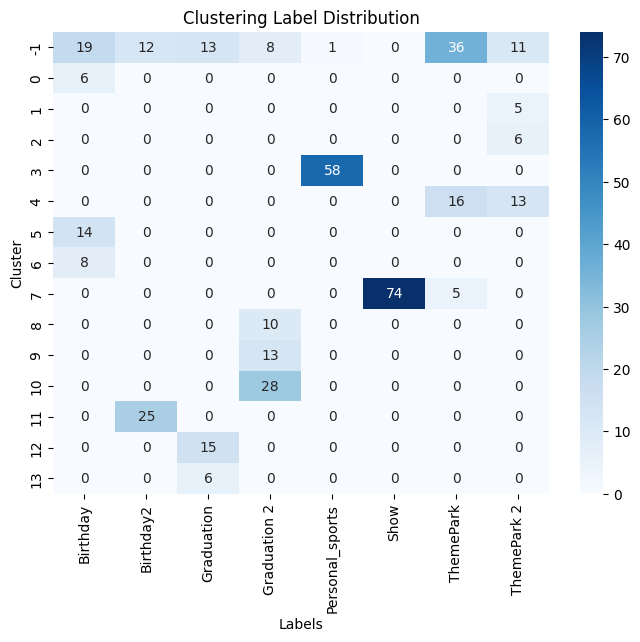

In [31]:
plot_cluster_distribution(y, y_pred, labels)

In [32]:
name_clusters(model, processor, y_pred, images, nlp, device)


Proposed Cluster Names:
Cluster 0: Proposed Name = 'city melbourne skyline'
Cluster 1: Proposed Name = 'man woman goofy'
Cluster 2: Proposed Name = 'group people picture'
Cluster 3: Proposed Name = 'boy skateboard trick'
Cluster 4: Proposed Name = 'water body pond'
Cluster 5: Proposed Name = 'table group people'
Cluster 6: Proposed Name = 'man suit tie'
Cluster 7: Proposed Name = 'man microphone scene'
Cluster 8: Proposed Name = 'woman girls dress'
Cluster 9: Proposed Name = 'woman man dress'
Cluster 10: Proposed Name = 'group people woman'
Cluster 11: Proposed Name = 'group people man'
Cluster 12: Proposed Name = 'group people woman'
Cluster 13: Proposed Name = 'people group crowd'


# Feature Embedding

## Create Model

In [33]:
class Feature_Embedder_v1(nn.Module):
    def __init__(self):
        super(Feature_Embedder_v1, self).__init__()
        # Define the fully connected layers
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)

        # Set activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Apply fully connected layers with ReLU activation
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        return x

In [34]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Linear(512, 256), 
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 768),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [35]:
class Clusterer(nn.Module):
    def __init__(self, embedder_model, clusterer):
        super(Clusterer, self).__init__()

        self.embedder_model = embedder_model
        self.clusterer = clusterer

    def forward(self, x):
        # get embedding space
        x = self.embedder_model(x)

        # get clusters
        _, x = cluster_images(self.clusterer, x.cpu().detach().numpy())

        x = torch.Tensor(x)

        return x

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch_directml

# Set device (DirectML or fallback to CPU)
device = torch_directml.device() if torch_directml.is_available() else torch.device('cpu')

# VAE Definition
class VAE(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=512, latent_dim=128):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Loss Function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL divergence loss
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

# Dummy training loop (replace with your own dataset like MNIST)
def train_vae(model, dataloader):
    # Dummy data: 1000 samples of 28x28 images (flattened)
    # x = torch.rand(1000, 784)
    # dataset = TensorDataset(x)
    # dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    epochs = 2000
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in dataloader:
            x_batch = batch[0].to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x_batch)
            loss = vae_loss(recon, x_batch, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

## Define Training and Testing Functions

In [37]:
def train_loop(num_epochs, dataloader, validation, model, clustering_model, optimizer, criterion, device, early_stop=5):
    train_loss_per_epoch = []
    validation_loss_per_epoch = []

    checkpoint_loss = torch.inf
    checkpoint = 0

    stagnant = 0
    stop = False

    model.train()  # Set the model to training mode
    for epoch in range(1, num_epochs + 1):
        if stop:
            break

        running_loss = 0.0
        for batch_idx, (img, label, _) in enumerate(dataloader):
            img, label = img.to(device), label.to(device)  # Move to GPU if available

            optimizer.zero_grad()  # Clear gradients

            # Forward pass
            output = model(img)

            # Calculate loss
            loss = criterion(output, label)

            # Backpropagation
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Log the loss every 20 batches
            # if batch_idx % 5 == 0:
            #     print(f'Epoch [{epoch}/{num_epochs}], Step [{batch_idx}/{len(dataloader)}], Loss: {loss.item():.4f}')
            img, label = img.cpu(), label.cpu()  # Move to CPU once done

        # Average loss after each epoch
        print(f'Epoch [{epoch}/{num_epochs}], Train Loss: {running_loss / len(dataloader):.4f}')
        train_loss_per_epoch.append(running_loss / len(dataloader))

        # validate model after each epoch
        with torch.no_grad():
            if validation != None:
                error = 0
                total = 0
                running_loss = 0.0
                for batch_idx, (img, label, _) in enumerate(validation):
                    img, label = img.to(device), label.to(device)  # Move to GPU if available

                    # Forward pass
                    output = model(img)

                    _, y_pred = cluster_images(clusterer=clustering_model, data=output.cpu())

                    acc, overall, unclustered = evaluate_clustering(y_pred=y_pred, y_true=label.cpu().squeeze().numpy())

                    # print(acc)
                    # print(overall)

                    # Calculate loss
                    output = model(img)

                    loss = criterion(output, label)
                    running_loss += loss.item()

                    # calculate Accuracy
                    if total == 0:
                        error = acc
                        overall_err = overall
                    else:
                        error = (error*total + acc*(label.shape[0]))/(total + label.shape[0])
                        overall_err = (overall_err*total + overall*(label.shape[0]))/(total + label.shape[0])

                    total += label.shape[0]

                    img, label = img.cpu(), label.cpu()  # Move to CPU once done

                if running_loss < checkpoint_loss:
                    checkpoint = epoch
                    checkpoint_loss = running_loss
                    stagnant = 0
                    torch.save(model.state_dict(), "model_state_dict.pth")
                else:
                    stagnant += 1
                    if stagnant >= early_stop:
                        stop = True
            
                print(f'Epoch [{epoch}/{num_epochs}], Clustered Percentage: {1-unclustered/total:.2%} Validation Accuracy: {error:.2%}, Overall Accuracy: {overall_err:.2%}')
                print(f'Epoch [{epoch}/{num_epochs}], Validation Loss: {running_loss / len(validation):.4f}')
                validation_loss_per_epoch.append(running_loss / len(validation))

    # load best parameters
    print(f'Best Model at {checkpoint} Epochs with loss of {checkpoint_loss}')
    print('Loading Best Model...')
    model.load_state_dict(torch.load("model_state_dict.pth"))

    return train_loss_per_epoch, validation_loss_per_epoch

In [38]:
def get_embeddings(dataloader, model, device):
    image_embeds_list = []

    model.to(device)

    with torch.no_grad():
        for batch_idx, (img, label, _) in enumerate(dataloader):
            img, label = img.to(device), label.to(device)  # Move to GPU if available

            output = model(img)

            image_embeds_list.append(output.cpu())

            img, label = img.cpu(), label.cpu()  # Move to CPU once done

    image_embeds = torch.cat(image_embeds_list, dim=0).numpy()
    
    model.cpu()

    return image_embeds

In [39]:
def get_embeddings_VAE(dataloader, model, device):
    image_embeds_list = []

    model.to(device)

    with torch.no_grad():
        for batch_idx, (img, label, _) in enumerate(dataloader):
            img, label = img.to(device), label.to(device)  # Move to GPU if available

            output = model.encode(img)

            print(output[0].shape)
            print(output[1].shape)

            output = torch.cat((output[0], output[1]), dim=-1)

            print(output.shape)

            image_embeds_list.append(output.cpu())

            img, label = img.cpu(), label.cpu()  # Move to CPU once done

    image_embeds = torch.cat(image_embeds_list, dim=0).numpy()
    
    model.cpu()

    return image_embeds

## Prepare for Training

In [40]:
# Check if DirectML is available and print the device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if GPU is available
if torch_directml.is_available():
    device = torch_directml.device(0)  # Using the first available device
    print("Using DirectML with GPU.")
else:
    print(f"Using {device}.")

Using DirectML with GPU.


In [41]:
# set image folder
image_locations = "./Albums_Not_Grouped"

# Initialize BLIP processor and model for image captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Load spaCy English model for NLP processing
nlp = spacy.load("en_core_web_sm")

In [42]:
# load data
images, y, labels = load_images_from_folder(root_folder=image_locations, image_size=(500,375))
X = get_blip_image_embedding_acc(model=model, processor=processor, images=images, device=device, batch_size=8)

In [43]:
# Transfer from nupmy array to tensor
Img_tensor = torch.Tensor(images)
X_tensor = torch.Tensor(X)
y_tensor = torch.Tensor(y).unsqueeze(dim=-1)

# Create the dataset
dataset=torch.utils.data.TensorDataset(X_tensor, y_tensor, Img_tensor)

#get data length
data_length = len(dataset)

print(data_length)

# set split factor (fraction of data sent to validation and training sets)
split_factor = 0.2 

#get set lengths
val_samples   = int(np.round(data_length * split_factor))
test_samples  = int(np.round(data_length * split_factor))
train_samples = data_length - 2 * test_samples

#split the dataset with random_split
train, val, test = torch.utils.data.random_split(dataset, [train_samples, val_samples, test_samples])

# Print the sizes of each split to verify
print(f'Training size: {len(train)}')
print(f'Validation size: {len(val)}')
print(f'Test size: {len(test)}')

#Create DataLoader objects for each dataset split
train_data = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)
val_data = torch.utils.data.DataLoader(val, batch_size=256, shuffle=False)
test_data = torch.utils.data.DataLoader(test, batch_size=256, shuffle=False)

402
Training size: 242
Validation size: 80
Test size: 80


In [44]:
# set hyperparameters
lr = 1e-4
margin = 1e1
num_epochs = 200

# establish models
# feature_embedding_model = Autoencoder() 

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
feature_embedding_model = Feature_Embedder_v1()
clustering_model = Clusterer(feature_embedding_model, hdbscan_model)

feature_embedding_model.to(device)

# loss_function = nn.MSELoss()
# optimizer = optim.Adam(feature_embedding_model.parameters(), lr=lr)
triplet_loss = nn.TripletMarginLoss(margin=margin)
bce_loss = nn.BCELoss()
loss_function = ModifiedTripletLoss(triplet_loss=triplet_loss, clusterer=hdbscan_model)#nn.MSELoss()
# loss_function = ModifiedBCE(bce_loss, hdbscan_model)
optimizer = optim.Adam(feature_embedding_model.parameters(), lr=lr)

## Train Model

In [45]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

train_loss, validation_loss = train_loop(num_epochs, train_data, val_data, feature_embedding_model, hdbscan_model, optimizer, loss_function, device, early_stop=50)

Epoch [1/200], Train Loss: 3797349.7500
Epoch [1/200], Clustered Percentage: 65.00% Validation Accuracy: 78.85%, Overall Accuracy: 51.25%
Epoch [1/200], Validation Loss: 75361.5625
Epoch [2/200], Train Loss: 3027638.0000
Epoch [2/200], Clustered Percentage: 57.50% Validation Accuracy: 97.83%, Overall Accuracy: 56.25%
Epoch [2/200], Validation Loss: 75720.9531
Epoch [3/200], Train Loss: 1748998.8750
Epoch [3/200], Clustered Percentage: 62.50% Validation Accuracy: 100.00%, Overall Accuracy: 62.50%
Epoch [3/200], Validation Loss: 56288.2734
Epoch [4/200], Train Loss: 1210760.2500
Epoch [4/200], Clustered Percentage: 72.50% Validation Accuracy: 100.00%, Overall Accuracy: 72.50%
Epoch [4/200], Validation Loss: 31000.1035
Epoch [5/200], Train Loss: 779178.5625
Epoch [5/200], Clustered Percentage: 77.50% Validation Accuracy: 93.55%, Overall Accuracy: 72.50%
Epoch [5/200], Validation Loss: 31620.0664
Epoch [6/200], Train Loss: 546641.5000
Epoch [6/200], Clustered Percentage: 81.25% Validation 

In [46]:
def plot_loss(train_losses, validation_losses):
  train_counter = list(range(1,len(train_losses)+1))
  fig = plt.figure()
  plt.plot(train_counter, train_losses, color='blue')
  plt.plot(train_counter, validation_losses, color='red')
  plt.legend(['Train Loss', 'Validation Loss'], loc='upper right')
  plt.xlabel('number of epochs')
  plt.ylabel('cross entropy loss')
  plt.show()

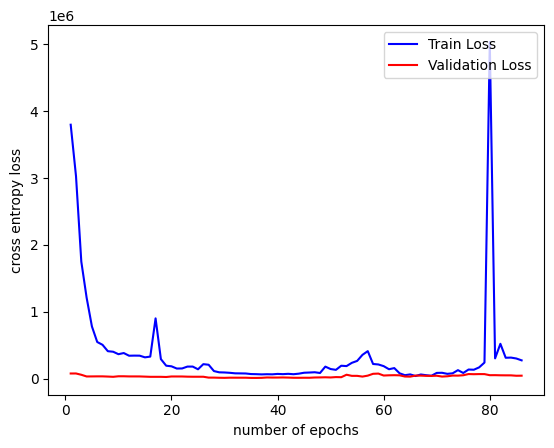

In [47]:
plot_loss(train_loss, validation_loss)

## Evaluate Feature Embedding

In [48]:
# get labels and images from dataloader
x_test = []
y_test = []
images_test = []

for batch in test_data:
    # Unpack the batch
    feat, lab, img = batch
    x_test.append(feat)
    y_test.append(lab)
    images_test.append(img)

# Concatenate all batches into single tensors
x_tensor = torch.cat(x_test, dim=0)
y_tensor = torch.cat(y_test, dim=0)
img_tensor = torch.cat(images_test, dim=0)

# Convert to NumPy arrays
x_test = x_tensor.numpy()
y_test = y_tensor.squeeze().numpy()
img_test = img_tensor.numpy()

In [49]:
test_embeddings = get_embeddings(test_data, feature_embedding_model, device)

In [50]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
# hdbscan_model = hdbscan_model.fit(all_embeddings)
# y_pred = hdbscan_model.fit_predict(test_embeddings)
hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=test_embeddings)

In [51]:
calculate_gini_loss_from_numpy(gini_loss, y_pred, y_test)

Clustered Gini Loss is: 12.918301582336426


tensor(12.9183)

In [52]:
avg_entropy, entropies = calculate_average_entropy(y_pred, y_test)

print(f"Wieghted Average Entropy: {avg_entropy:.4f}")

for i in range(len(entropies)):
    print(f"Cluster {i} Entropy: {entropies[i]:.4f}")

Wieghted Average Entropy: 0.5872
Cluster 0 Entropy: 0.4690
Cluster 1 Entropy: -0.0000
Cluster 2 Entropy: -0.0000
Cluster 3 Entropy: 1.3534


Number of unassigned images: 19 (23.75%)%
Cluster 0: True Label = 'ThemePark'
Cluster 1: True Label = 'Show'
Cluster 2: True Label = 'Personal_sports'
Cluster 3: True Label = 'Graduation 2'


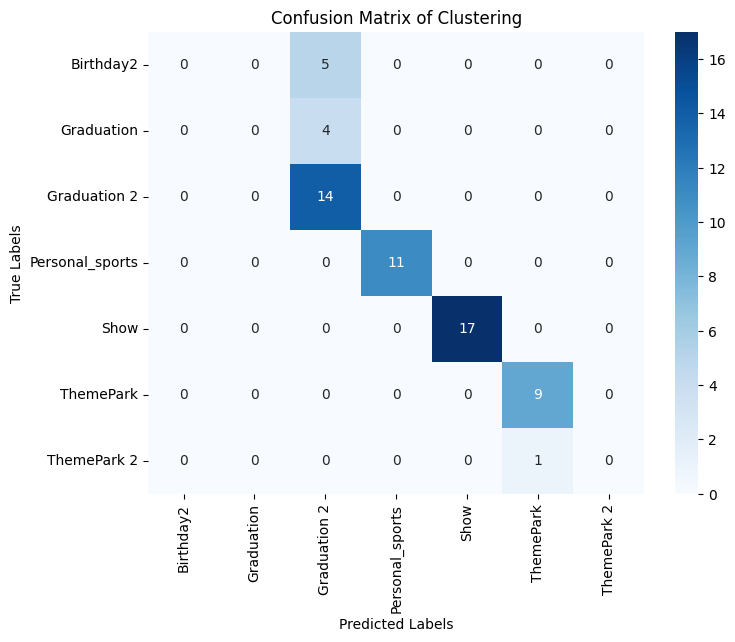

Clustering accuracy: 83.61% (Overall: 63.75%)


In [53]:
# evaluate model
acc = evaluate_clustering(y_pred=y_pred, label_names=labels, y_true=y_test, output_text=True)

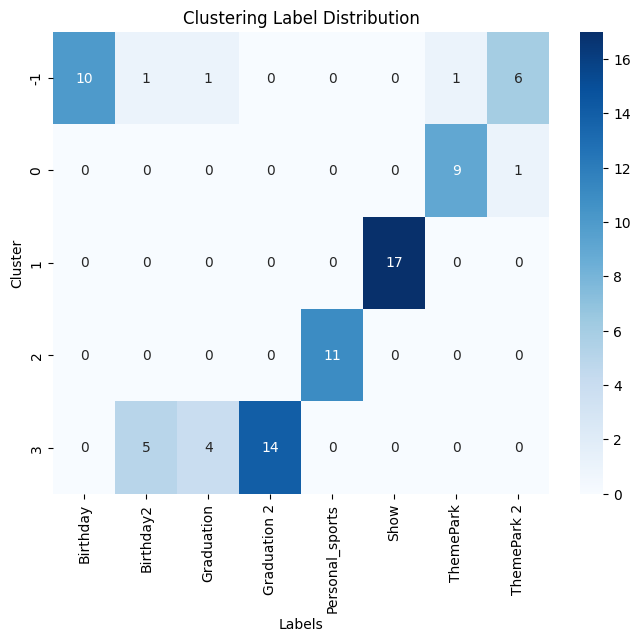

In [54]:
plot_cluster_distribution(y_test, y_pred, labels)

In [55]:
name_clusters(model, processor, y_pred, img_test, nlp, device)


Proposed Cluster Names:
Cluster 0: Proposed Name = 'sky window wall'
Cluster 1: Proposed Name = 'man suit shirt'
Cluster 2: Proposed Name = 'skateboard boy trick'
Cluster 3: Proposed Name = 'woman group people'


## Test Set without Feature Embedding Layer

In [56]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
# hdbscan_model = hdbscan_model.fit(all_embeddings)
# y_pred = hdbscan_model.fit_predict(test_embeddings)
hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=x_test)

In [57]:
calculate_gini_loss_from_numpy(gini_loss, y_pred, y_test)

Clustered Gini Loss is: 16.42552947998047


tensor(16.4255)

In [58]:
avg_entropy, entropies = calculate_average_entropy(y_pred, y_test)

print(f"Wieghted Average Entropy: {avg_entropy:.4f}")

for i in range(len(entropies)):
    print(f"Cluster {i} Entropy: {entropies[i]:.4f}")

Wieghted Average Entropy: 0.4950
Cluster 0 Entropy: -0.0000
Cluster 1 Entropy: 0.9183
Cluster 2 Entropy: -0.0000
Cluster 3 Entropy: 1.0863


Number of unassigned images: 26 (32.50%)%
Cluster 0: True Label = 'Personal_sports'
Cluster 1: True Label = 'ThemePark'
Cluster 2: True Label = 'Show'
Cluster 3: True Label = 'Graduation 2'


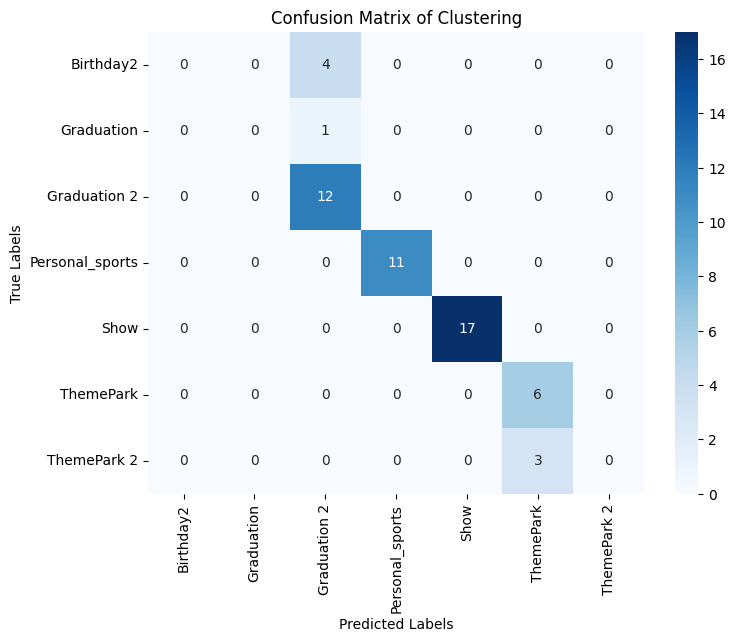

Clustering accuracy: 85.19% (Overall: 57.50%)


In [59]:
# evaluate model
acc = evaluate_clustering(y_pred=y_pred, label_names=labels, y_true=y_test, output_text=True)

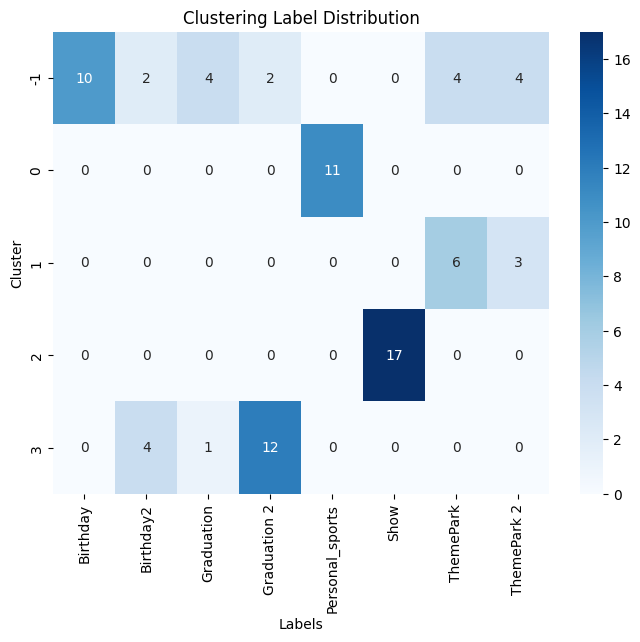

In [60]:
plot_cluster_distribution(y_test, y_pred, labels)

In [61]:
name_clusters(model, processor, y_pred, img_test, nlp, device)


Proposed Cluster Names:
Cluster 0: Proposed Name = 'boy skateboard park'
Cluster 1: Proposed Name = 'woman chair pole'
Cluster 2: Proposed Name = 'man suit guitar'
Cluster 3: Proposed Name = 'group people woman'


## Naive HDBSCAN Clustering

In [62]:
type(img_test)

numpy.ndarray

In [63]:
img_test_flat = img_test.reshape(img_test.shape[0], -1)
img_test_flat.shape

(80, 562500)

In [64]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
# hdbscan_model = hdbscan_model.fit(all_embeddings)
# y_pred = hdbscan_model.fit_predict(test_embeddings)
hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=img_test_flat)

In [65]:
calculate_gini_loss_from_numpy(gini_loss, y_pred, y_test)

Clustered Gini Loss is: 40.0


tensor(40.)

In [66]:
avg_entropy, entropies = calculate_average_entropy(y_pred, y_test)

print(f"Weighted Average Entropy: {avg_entropy:.4f}")

for i in range(len(entropies)):
    print(f"Cluster {i} Entropy: {entropies[i]:.4f}")

Weighted Average Entropy: -1.0000


In [67]:
# evaluate model
acc = evaluate_clustering(y_pred=y_pred, label_names=labels, y_true=y_test, output_text=True)

Number of unassigned images: 80 (100.00%)%
Clustering accuracy: 0.00% (Overall: 0.00%)


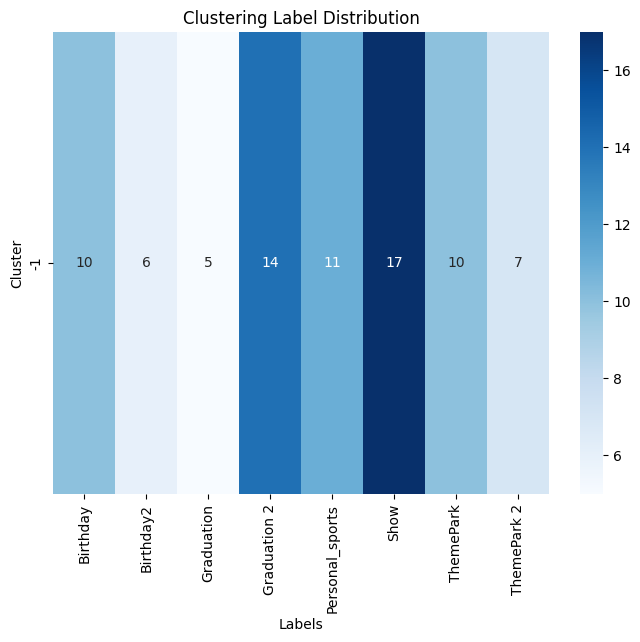

In [68]:
plot_cluster_distribution(y_test, y_pred, labels)

In [69]:
name_clusters(model, processor, y_pred, img_test, nlp, device)


Proposed Cluster Names:


# Multi-Model Variance and Mean of Accuracy and Entropy

In [61]:
import warnings

num_times = 10

acc_list_V0 = []
entropy_list_V0 = []
acc_list_V1 = []
entropy_list_V1 = []
acc_list_V2 = []
entropy_list_V2 = []

# Check if DirectML is available and print the device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if GPU is available
if torch_directml.is_available():
    device = torch_directml.device(0)  # Using the first available device
    print("Using DirectML with GPU.")
else:
    print(f"Using {device}.")

# set image folder
image_locations = "./Albums_Not_Grouped"

# Initialize BLIP processor and model for image captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Load spaCy English model for NLP processing
nlp = spacy.load("en_core_web_sm")

# load data
images, y, labels = load_images_from_folder(root_folder=image_locations, image_size=(500,375))
X = get_blip_image_embedding_acc(model=model, processor=processor, images=images, device=device, batch_size=8)

# Transfer from nupmy array to tensor
Img_tensor = torch.Tensor(images)
X_tensor = torch.Tensor(X)
y_tensor = torch.Tensor(y).unsqueeze(dim=-1)

# Create the dataset
dataset=torch.utils.data.TensorDataset(X_tensor, y_tensor, Img_tensor)

#get data length
data_length = len(dataset)

print(data_length)

# set split factor (fraction of data sent to validation and training sets)
split_factor = 0.2 

#get set lengths
val_samples   = int(np.round(data_length * split_factor))
test_samples  = int(np.round(data_length * split_factor))
train_samples = data_length - 2 * test_samples

for i in range(num_times):
    #split the dataset with random_split
    train, val, test = torch.utils.data.random_split(dataset, [train_samples, val_samples, test_samples])

    # Print the sizes of each split to verify
    print(f'Training size: {len(train)}')
    print(f'Validation size: {len(val)}')
    print(f'Test size: {len(test)}')

    #Create DataLoader objects for each dataset split
    train_data = torch.utils.data.DataLoader(train, batch_size=256, shuffle=True)
    val_data = torch.utils.data.DataLoader(val, batch_size=256, shuffle=False)
    test_data = torch.utils.data.DataLoader(test, batch_size=256, shuffle=False)

    # set hyperparameters
    lr = 1e-4
    margin = 1e1
    num_epochs = 200

    # establish models
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
    feature_embedding_model = Feature_Embedder_v1()
    clustering_model = Clusterer(feature_embedding_model, hdbscan_model)

    feature_embedding_model.to(device)

    triplet_loss = nn.TripletMarginLoss(margin=margin)
    loss_function = ModifiedTripletLoss(triplet_loss=triplet_loss, clusterer=hdbscan_model)#nn.MSELoss()
    optimizer = optim.Adam(feature_embedding_model.parameters(), lr=lr)

    # Suppress all warnings
    warnings.filterwarnings("ignore")

    train_loss, validation_loss = train_loop(num_epochs, train_data, val_data, feature_embedding_model, hdbscan_model, optimizer, loss_function, device, early_stop=50)

    # get labels and images from dataloader
    x_test = []
    y_test = []
    images_test = []

    for batch in test_data:
        # Unpack the batch
        feat, lab, img = batch
        x_test.append(feat)
        y_test.append(lab)
        images_test.append(img)

    # Concatenate all batches into single tensors
    x_tensor = torch.cat(x_test, dim=0)
    y_tensor = torch.cat(y_test, dim=0)
    img_tensor = torch.cat(images_test, dim=0)

    # Convert to NumPy arrays
    x_test = x_tensor.numpy()
    y_test = y_tensor.squeeze().numpy()
    img_test = img_tensor.numpy()

    test_embeddings = get_embeddings(test_data, feature_embedding_model, device)

    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
    hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=test_embeddings)

    avg_entropy, entropies = calculate_average_entropy(y_pred, y_test)

    acc = evaluate_clustering(y_pred=y_pred, y_true=y_test)

    acc_list_V2.append(acc)
    entropy_list_V2.append(avg_entropy)

    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
    hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=x_test)

    avg_entropy, entropies = calculate_average_entropy(y_pred, y_test)

    acc = evaluate_clustering(y_pred=y_pred, y_true=y_test)

    acc_list_V1.append(acc)
    entropy_list_V1.append(avg_entropy)

    img_test_flat = img_test.reshape(img_test.shape[0], -1)
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
    hdbscan_model, y_pred = cluster_images(clusterer=hdbscan_model, data=img_test_flat)

    avg_entropy, entropies = calculate_average_entropy(y_pred, y_test)

    acc = evaluate_clustering(y_pred=y_pred, y_true=y_test)

    acc_list_V0.append(acc)
    entropy_list_V0.append(avg_entropy)


Using DirectML with GPU.
402
Training size: 242
Validation size: 80
Test size: 80
Epoch [1/200], Train Loss: 2797524.5000
Epoch [1/200], Clustered Percentage: 52.50% Validation Accuracy: 69.05%, Overall Accuracy: 36.25%
Epoch [1/200], Validation Loss: 127195.5703
Epoch [2/200], Train Loss: 2358179.2500
Epoch [2/200], Clustered Percentage: 55.00% Validation Accuracy: 70.45%, Overall Accuracy: 38.75%
Epoch [2/200], Validation Loss: 114541.0859
Epoch [3/200], Train Loss: 2308385.0000
Epoch [3/200], Clustered Percentage: 57.50% Validation Accuracy: 67.39%, Overall Accuracy: 38.75%
Epoch [3/200], Validation Loss: 109995.8438
Epoch [4/200], Train Loss: 1444731.0000
Epoch [4/200], Clustered Percentage: 55.00% Validation Accuracy: 88.64%, Overall Accuracy: 48.75%
Epoch [4/200], Validation Loss: 100341.8359
Epoch [5/200], Train Loss: 1348623.2500
Epoch [5/200], Clustered Percentage: 92.50% Validation Accuracy: 27.03%, Overall Accuracy: 25.00%
Epoch [5/200], Validation Loss: 402237.3125
Epoch [6

In [62]:
mean = np.mean(np.array(acc_list_V2), axis=0)
std = np.std(np.array(acc_list_V2), axis=0)

print(f"Accuracy: {mean[0]:.2%}, sigma {std[0]:.2%}")
print(f"Overall: {mean[1]:.2%}, sigma {std[1]:.2%}")
print(f"Unclustered Images: {mean[2]:.2f}, sigma {std[2]:.2f}")

Accuracy: 76.33%, sigma 21.28%
Overall: 62.88%, sigma 14.94%
Unclustered Images: 12.60, sigma 7.10


In [63]:
print(f"Weighted Average Entropy: {np.mean(entropy_list_V2):.4f}, sigma {np.std(entropy_list_V2):.4f}")

Weighted Average Entropy: 0.8064, sigma 0.7378


In [64]:
mean = np.mean(np.array(acc_list_V1), axis=0)
std = np.std(np.array(acc_list_V1), axis=0)

print(f"Accuracy: {mean[0]:.2%}, sigma {std[0]:.2%}")
print(f"Overall: {mean[1]:.2%}, sigma {std[1]:.2%}")
print(f"Unclustered Images: {mean[2]:.2f}, sigma {std[2]:.2f}")

Accuracy: 88.06%, sigma 7.41%
Overall: 56.12%, sigma 8.92%
Unclustered Images: 28.90, sigma 7.61


In [65]:
print(f"Weighted Average Entropy: {np.mean(entropy_list_V1):.4f}, sigma {np.std(entropy_list_V1):.4f}")

Weighted Average Entropy: 0.3963, sigma 0.2500


In [66]:
mean = np.mean(np.array(acc_list_V0), axis=0)
std = np.std(np.array(acc_list_V0), axis=0)

print(f"Accuracy: {mean[0]:.2%}, sigma {std[0]:.2%}")
print(f"Overall: {mean[1]:.2%}, sigma {std[1]:.2%}")
print(f"Unclustered Images: {mean[2]:.2f}, sigma {std[2]:.2f}")

Accuracy: 38.54%, sigma 7.53%
Overall: 9.25%, sigma 1.50%
Unclustered Images: 60.50, sigma 3.17


In [67]:
print(f"Weighted Average Entropy: {np.mean(entropy_list_V0):.4f}, sigma {np.std(entropy_list_V0):.4f}")

Weighted Average Entropy: 1.9366, sigma 0.1928


# Test Zone (Enter at Your Own Risk!)

In [121]:
class ModifiedTripletLoss(nn.Module):
    """
    Computes Triplet Loss for Clusters

    Args:
        alpha - punishes model for unclustered datapoints
    """
    def __init__(self, triplet_loss, clusterer):
        super(ModifiedTripletLoss, self).__init__()
        self.triplet_loss = triplet_loss
        self.clusterer = clusterer

    def forward(self, embeddings, y_true):

        # get clusters
        _, y_pred = cluster_images(self.clusterer, embeddings.cpu().detach().numpy())

        device = embeddings.device
        embeddings = embeddings.cpu()

        # y_pred = torch.Tensor(y_pred)#.to(device)

        # initialize loss
        loss_value = 0.0

        # get clusters
        clusters = np.unique(y_pred)#.cpu().unique(return_counts=True)

        y_true = y_true.squeeze().cpu().detach().numpy()
        
        # # get class labels
        # labels, label_counts = y_true.cpu().unique(return_counts=True)

        for cluster in clusters:
            # print(cluster)

            idx_mask = y_pred == cluster
            indices = np.where(y_pred == cluster)

            for idx in indices[0]:
                if cluster == -1:
                    pos_indices = np.where(y_true == y_true[idx])
                else:
                    pos_indices = np.where((y_true == y_true[idx]) & idx_mask)

                neg_indices = np.where((y_true != y_true[idx]) & idx_mask)

                for p_idx in pos_indices[0]:
                    if p_idx != idx:
                        for n_idx in neg_indices[0]: 
                            loss_value += self.triplet_loss(embeddings[idx], embeddings[p_idx], embeddings[n_idx])
                    else:
                        pass

        # return loss value
        return loss_value

In [122]:
import torch

def something(clusterer, triplet_loss, embeddings, y_true):
    # Get clusters using the clusterer and move to the device
    _, y_pred = cluster_images(clusterer, embeddings.cpu().detach().numpy())
    y_pred = torch.tensor(y_pred, device=embeddings.device)  # Convert y_pred back to tensor
    
    device = embeddings.device
    
    # Initialize loss
    loss_value = 0.0
    
    # Get unique clusters (including -1)
    clusters = torch.unique(y_pred)
    
    y_true = y_true.squeeze()

    # Create a mask for each cluster
    for cluster in clusters:
        # Create a mask to find elements that belong to the current cluster
        idx_mask = y_pred == cluster
        
        # For each cluster, compute pairwise positive and negative indices
        cluster_indices = torch.nonzero(idx_mask).squeeze()
        
        if cluster == -1:
            # For -1 (outliers), find all positive and negative pairs for all samples in this cluster
            pos_mask = y_true.unsqueeze(1) == y_true.unsqueeze(0)  # All pairs where y_true is the same
            # neg_mask = y_true.unsqueeze(1) != y_true.unsqueeze(0)  # All pairs where y_true is different
            neg_mask = (y_true.unsqueeze(1) != y_true.unsqueeze(0)) & idx_mask.unsqueeze(0)
        else:
            # For other clusters, apply the cluster mask
            pos_mask = (y_true.unsqueeze(1) == y_true.unsqueeze(0)) & idx_mask.unsqueeze(0)  # Positive pairs
            neg_mask = (y_true.unsqueeze(1) != y_true.unsqueeze(0)) & idx_mask.unsqueeze(0)  # Negative pairs

        # Get indices for positive and negative pairs
        pos_indices = torch.nonzero(pos_mask).squeeze()
        neg_indices = torch.nonzero(neg_mask).squeeze()

        # Ensure that we don't use the same index for positive and negative pairs
        pos_indices = pos_indices[pos_indices[:, 0] != pos_indices[:, 1]]  # Remove self-pairs

        # Compute triplet loss for all positive-negative pairs in a vectorized manner
        # For each anchor, we calculate the loss with all positives and negatives
        anchor_embeddings = embeddings[pos_indices[:, 0]]  # Get anchor embeddings
        positive_embeddings = embeddings[pos_indices[:, 1]]  # Get positive embeddings
        negative_embeddings = embeddings[neg_indices[:, 1]]  # Get negative embeddings
        
        # Calculate triplet loss for each pair
        for anchor, positive, negative in zip(anchor_embeddings, positive_embeddings, negative_embeddings):
            loss_value += triplet_loss(anchor, positive, negative)

    return loss_value
